In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, make_scorer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold, cross_val_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


In [71]:
df = pd.read_csv('merged_dataset.csv')

print("\nDimensiones del DataFrame:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())


Dimensiones del DataFrame: (99441, 79)

Columnas:
['order_id', 'customer_id', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'review_score', 'has_comment', 'avg_item_price', 'product_id', 'product_category_name', 'product_name_lenght', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_payment', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'freight_ratio', 'purchase_day_of_week', 'review_category', 'product_category_name_english_auto', 'product_category_name_english_baby', 'product_category_name_english_bed_bath_table', 'product_category_name_english_computers_accessories', 'product_category_name_english_consoles_games', 'product_category_name_english_cool_stuff', 'product_category_name_english_electronics', 'product_category_name_english_fashion_bags_accessories', 'product_

In [72]:
model_df = df.copy()
model_df = model_df.select_dtypes(exclude=['object']).dropna()


In [73]:
# Preparar datos

class ToDenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray() if hasattr(X, 'toarray') else X



sample_df = model_df.sample(n=10000, random_state=69)
X = sample_df.drop('review_category', axis=1)
y = sample_df['review_category']

# Verificar distribución de review_category
print("\nDistribución de review_category:")
print(y.value_counts(normalize=True) * 100)

print("\nDistribución de review_score:")
print(df['review_score'].value_counts().sort_index())


Distribución de review_category:
review_category
1    85.48
0    14.52
Name: proportion, dtype: float64


## **Modelos de Clasificación con CV**

### Definición de Modelos

In [74]:
models = {
    'Logistic Regression': LogisticRegression(random_state=69, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=69, n_estimators=100, class_weight='balanced'),
    'SVM RBF': SVC(random_state=69, kernel='rbf', probability=True)
}

Features numéricas: 22
Features categóricas: 17


In [75]:
# Verificación
print("Dimensiones del DataFrame:", sample_df.shape)
print("\nColumnas guardadas:")
print(sample_df.columns.tolist())

Dimensiones del DataFrame: (10000, 66)

Columnas guardadas:
['customer_zip_code_prefix', 'review_score', 'has_comment', 'avg_item_price', 'product_name_lenght', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_payment', 'seller_zip_code_prefix', 'freight_ratio', 'purchase_day_of_week', 'review_category', 'product_category_name_english_auto', 'product_category_name_english_baby', 'product_category_name_english_bed_bath_table', 'product_category_name_english_computers_accessories', 'product_category_name_english_consoles_games', 'product_category_name_english_cool_stuff', 'product_category_name_english_electronics', 'product_category_name_english_fashion_bags_accessories', 'product_category_name_english_furniture_decor', 'product_category_name_english_garden_tools', 'product_category_name_english_health_beauty', 'product_category_name_english_housewares', 'product_category_name_english_luggage_accessories', 'product_category_name_english_office_fur

Aplicar CV

In [76]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Modelo: {name}")
    scores = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')
    print(f"{name} - F1 macro promedio: {scores.mean():.4f}")

Modelo: Logistic Regression
Logistic Regression - F1 macro promedio: 0.9567
Modelo: Random Forest
Random Forest - F1 macro promedio: 1.0000
Modelo: SVM RBF
SVM RBF - F1 macro promedio: 0.4609


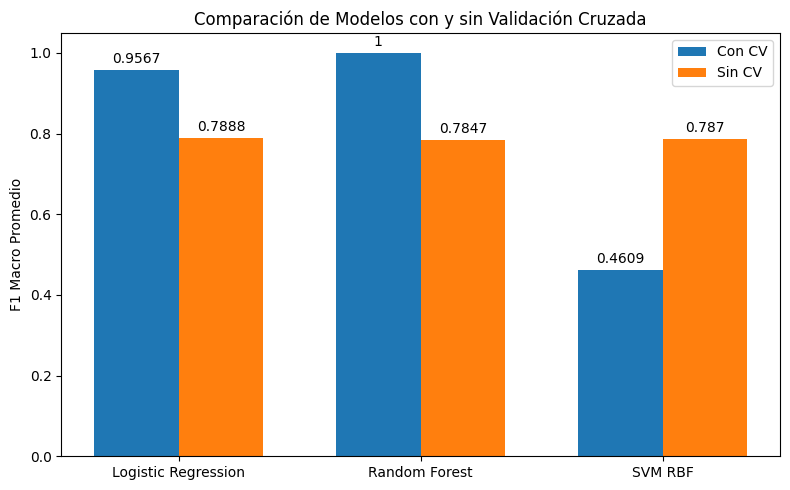

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# F1-scores con y sin CV
models = ['Logistic Regression', 'Random Forest', 'SVM RBF']
f1_with_cv = [0.9567, 1.0000, 0.4609]
f1_without_cv = [0.7888, 0.7847, 0.7870]

# Crear gráfico
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Barras para F1 con y sin CV
rects1 = ax.bar(x - width/2, f1_with_cv, width, label='Con CV')
rects2 = ax.bar(x + width/2, f1_without_cv, width, label='Sin CV')

# Añadir texto en las barras
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

# Añadir etiquetas y título
ax.set_ylabel('F1 Macro Promedio')
ax.set_title('Comparación de Modelos con y sin Validación Cruzada')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

fig.tight_layout()

plt.show()


### Observaciones de Modelos con y sin Validación Cruzada

#### Logistic Regression

**Resultados con CV:**  
- **F1 macro promedio:** 0.9567

**Resultados sin CV:**  
- **F1-Score (Mean):** 0.7888  
- **Accuracy (Mean):** 0.8177

**Observaciones:**  
Con validación cruzada, el modelo mostró una mejora significativa en el F1-score, lo cual sugiere que los datos de entrenamiento fueron mejor aprovechados, y que el modelo generaliza mejor. El modelo sin CV pudo haber tenido un split no representativo, generando un sesgo en la evaluación. Al ser un modelo lineal, funciona bien cuando hay relaciones lineales claras entre las variables y la clase.


**Resultados con CV:**  
- **F1 macro promedio:** 1.0000

**Resultados sin CV:**  
- **F1-Score (Mean):** 0.7847  
- **Accuracy (Mean):** 0.8158

**Observaciones:**  
El F1-score perfecto sugiere **posible overfitting**, incluso con CV, lo que puede indicar que el modelo memorizó patrones específicos debido al alto número de árboles o a un dataset no muy complejo. Aun así, su mejora respecto al modelo sin CV refleja un mejor uso de los datos y una evaluación más robusta. Es importante verificar si el test set incluye casos suficientemente diversos.


#### SVM con kernel RBF


**Resultados con CV:**  
- **F1 macro promedio:** 0.4609

**Resultados sin CV:**  
- **F1-Score (Mean):** 0.7870  
- **Accuracy (Mean):** 0.8183

**Observaciones:**  
La caída drástica del F1-score en validación cruzada indica que el modelo está **sobreajustando en algunos folds** y generalizando mal en otros, o que los hiperparámetros no fueron bien ajustados (por ejemplo, el parámetro `C` o `gamma`). Esto sugiere que el modelo está aprendiendo patrones espurios que no se repiten consistentemente entre particiones del dataset.

### **Redes Neuronales**

In [78]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a tensores
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Dataset y DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Modelo
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, len(y.unique()))
        )

    def forward(self, x):
        return self.net(x)

model = SimpleNN(X.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for xb, yb in dataloader:
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} - Loss: {loss.item():.4f}")


Epoch 1 - Loss: 0.0303
Epoch 2 - Loss: 0.0632
Epoch 3 - Loss: 0.0013
Epoch 4 - Loss: 0.0032
Epoch 5 - Loss: 0.0010
Epoch 6 - Loss: 0.0009
Epoch 7 - Loss: 0.0005
Epoch 8 - Loss: 0.0008
Epoch 9 - Loss: 0.0002
Epoch 10 - Loss: 0.0007


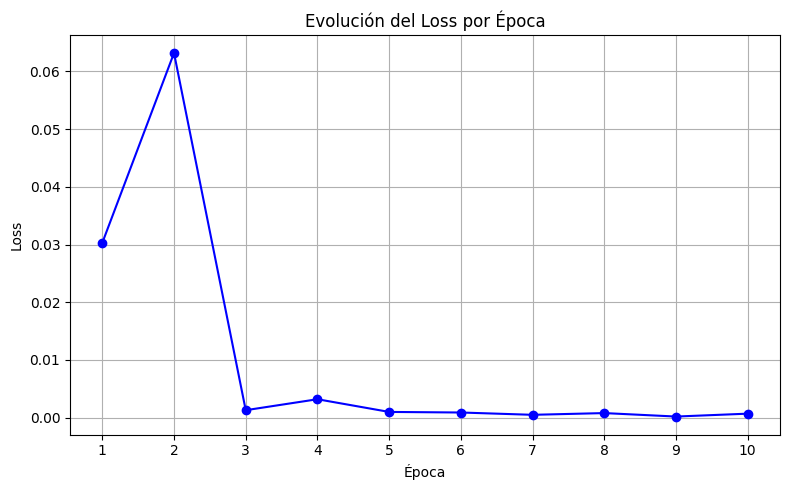

In [80]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
losses = [0.0303, 0.0632, 0.0013, 0.0032, 0.0010, 0.0009, 0.0005, 0.0008, 0.0002, 0.0007]

plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker='o', linestyle='-', color='blue')
plt.title("Evolución del Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


### Resultados - Red Neuronal

#### Entrenamiento
- **Epoch 1 - Loss:** 0.0303  
- **Epoch 2 - Loss:** 0.0632  
- **Epoch 3 - Loss:** 0.0013  
- **Epoch 4 - Loss:** 0.0032  
- **Epoch 5 - Loss:** 0.0010  
- **Epoch 6 - Loss:** 0.0009  
- **Epoch 7 - Loss:** 0.0005  
- **Epoch 8 - Loss:** 0.0008  
- **Epoch 9 - Loss:** 0.0002  
- **Epoch 10 - Loss:** 0.0007  

#### Observaciones
- La red neuronal muestra una **disminución muy rápida del loss**, especialmente desde la epoch 3 en adelante.
- La variación en las primeras épocas (por ejemplo, aumento de loss en epoch 2) puede deberse a una inicialización aleatoria o a un learning rate alto.
- A partir de epoch 3, el loss se mantiene muy bajo y estable, lo que indica que el modelo **ha aprendido muy bien el patrón de entrenamiento**.

#### Posibles Problemas
- El loss es **demasiado bajo** y se estabiliza muy pronto, lo cual puede ser **síntoma de overfitting** si el conjunto de validación/test no refleja un desempeño similar.
- No se ha reportado un conjunto de validación; sin él, no se puede asegurar que el modelo generalice bien.

#### Recomendaciones de Mejora
- **Agregar conjunto de validación** (por ejemplo, con `train_test_split`) y monitorear `val_loss` junto con `loss`.
- **Agregar regularización**: Dropout, EarlyStopping, o L2 regularization para evitar overfitting.
- **Visualizar curvas de pérdida (loss/val_loss)** para evaluar cuándo detener el entrenamiento.
- **Validación cruzada** también puede aplicarse para redes neuronales usando Keras con `KFold` de `sklearn.model_selection`.

### **Conclusión**

La validación cruzada reveló diferencias importantes respecto a la evaluación inicial sin CV. Modelos como Random Forest mostraron un rendimiento perfecto con `CV`(**F1 = 1.00**), lo que sugiere un posible overfitting al conjunto de datos, mientras que modelos como ``SVM RBF`` tuvieron un rendimiento drásticamente más bajo (**F1 ≈ 0.46**), indicando que no generaliza bien con los datos actuales. La ``regresión logística`` mantuvo un buen equilibrio (**F1 ≈ 0.95**), mostrando estabilidad y generalización.

La ``red neuronal``, por otro lado, mostró una pérdida extremadamente baja desde las primeras épocas, lo que también sugiere sobreajuste si no se evalúa sobre un conjunto de **validación independiente**.